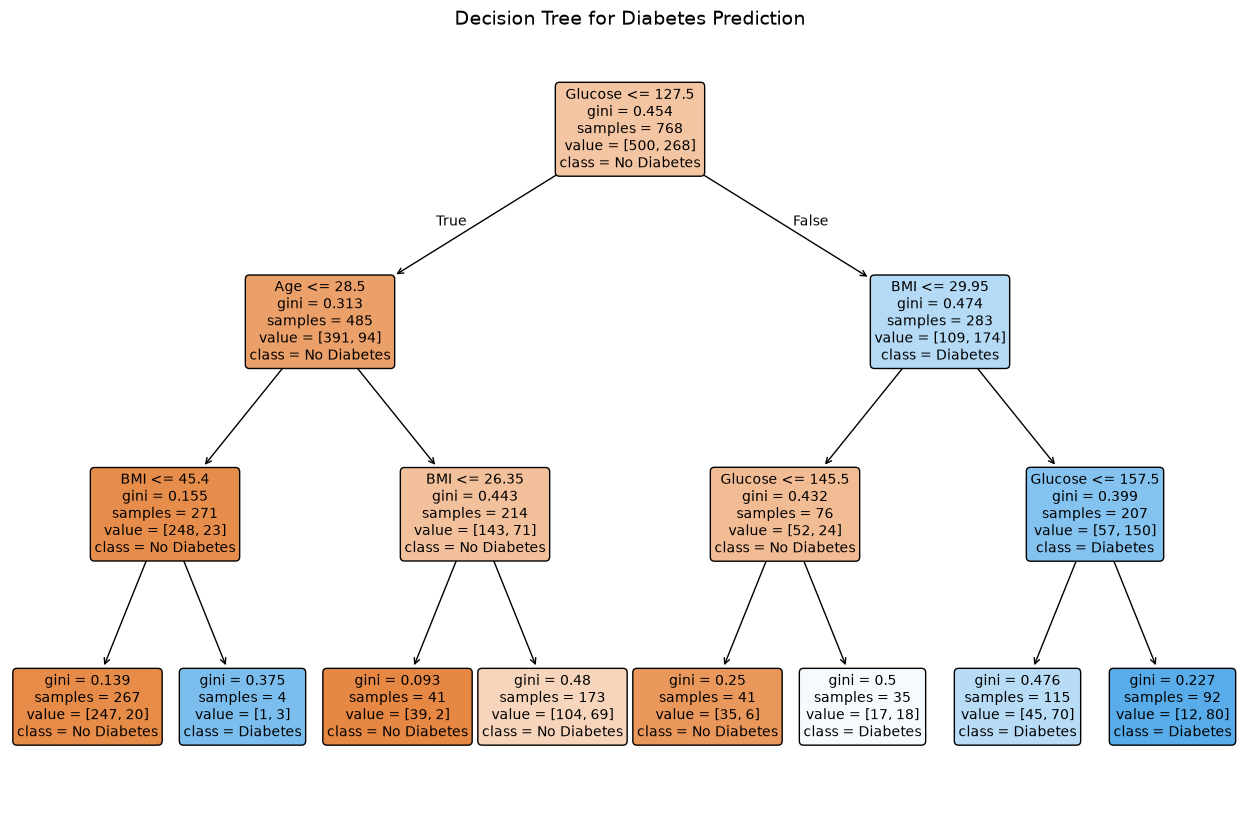

EXTRACTED DECISION TREE RULES:
|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 45.40
|   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- class: 1
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- class: 0
|--- Glucose >  127.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 145.50
|   |   |   |--- class: 0
|   |   |--- Glucose >  145.50
|   |   |   |--- class: 1
|   |--- BMI >  29.95
|   |   |--- Glucose <= 157.50
|   |   |   |--- class: 1
|   |   |--- Glucose >  157.50
|   |   |   |--- class: 1



In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# 1. Load the dataset
df = pd.read_csv(r"/workspaces/Strategic_Segment_Builder/diabetes.csv")

# 2. Separate independent features from target response matrix
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# 3. Initialize and fit shallow tree to keep rule extraction interpretive
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# 4. Generate the High-Resolution Plot Graph
plt.figure(figsize=(16, 10))
plot_tree(
    clf, 
    feature_names=X.columns, 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Decision Tree for Diabetes Prediction", fontsize=14)
plt.savefig("diabetes_tree.png", bbox_inches="tight", dpi=300)
plt.show()

# 5. Extract and print raw split decisions as plain text rules
tree_rules = export_text(clf, feature_names=list(X.columns))
print("=" * 50)
print("EXTRACTED DECISION TREE RULES:")
print("=" * 50)
print(tree_rules)

In [2]:
from segmentiq import *

In [11]:
my_search_grid = {
    "min_sample_size": [10000,5000, 1000],  # Example values for min_sample_size   
    "min_lift": [2.0,1.5]
}


# Initialize the builder
builder = StrategicSegmentBuilder(
    target="Outcome",
    # n_jobs=-1,
    min_sample_size=0,
    min_lift=1.0,
    min_events = 0,
    top_n_vars=15,
    max_segments=10,
    enable_diversity=False,
    max_feature_reuse=99,
    enable_1way=True,  # Include 1-way rules from final output
    enable_2way=True,  # Exclude 2-way rules from final output
    enable_3way=True,  # Exclude 3-way rules from final output
    feature_groups=None,
    ignore_features=None,
    param_grid=my_search_grid
)


data = UniversalDataLoader(file_path=r"/workspaces/Strategic_Segment_Builder/diabetes.csv").load()

segments_df = builder.extract_segments(data)
final_eval = builder.evaluate_final_coverage(data)

2026-07-12 13:52:22,678 | INFO     | [builder.py:337] | DuckDB Configured: Threads=4/4, MemoryLimit=7GB
2026-07-12 13:52:22,688 | INFO     | [builder.py:352] | Dynamic Grid Search Enabled: 6 total configurations.
